# Laboratorio 7 — Spark MLlib

Análisis exploratorio y segmentación de salarios mensuales de personas asalariadas con las bases de **Personas** de la Encuesta Nacional de Empleo e Ingresos Continua (ENEIC, INE Guatemala), usando Python y Spark 3.5 (`pyspark.ml`).

- **Desarrollo:** cuatro trimestres de 2025. **Prueba final:** primer trimestre de 2026.
- **Población analítica:** 15 años o más, ocupadas (`OCUPADOS = 1`), asalariadas (`P05C16` en 1–4) y con `P05D01` numérico, finito y positivo.
- Clustering, estadísticas y métricas son **no ponderados**: describen los registros analizados y no son estimaciones oficiales de la población. Las asociaciones no implican causalidad.

Contenido:

1. Carga, armonización y calidad de datos (actividad 1).
2. Estadística descriptiva, exploración y correlaciones (actividades 2 y 3).
3. Segmentación de perfiles mediante KMeans (actividad 4).

El notebook se ejecuta de principio a fin con una sola sesión de Spark; la lógica reutilizable está en `src/` y tiene pruebas en `tests/`.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

from src import config, carga, calidad, exploracion, segmentacion

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

for d in (config.FIGURES, config.TABLES, config.MODELOS):
    d.mkdir(parents=True, exist_ok=True)

spark = config.crear_spark("lab7")
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

26/09/24 16:46:53 WARN Utils: Your hostname, MacBook-Pro-de-Joel-2.local resolves to a loopback address: 127.0.0.1; using 192.168.0.20 instead (on interface en0)
26/09/24 16:46:53 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 16:46:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.9


# Parte 1 · Carga, armonización y calidad de datos

Este notebook prepara la población analítica de salarios de personas asalariadas con las bases de **Personas** de la ENEIC:

- **2025 (I a IV)**: desarrollo y entrenamiento.
- **2026 (I)**: prueba final.

Pasos: identificar la procedencia de cada archivo, seleccionar y homologar columnas, unir los cuatro archivos de 2025 con `unionByName`, medir faltantes, aplicar los filtros en un orden fijo, verificar la unicidad de las claves y guardar los conjuntos preparados en Parquet.

Las bases se leen con pandas/openpyxl **una por una**, se convierten a Spark con tipos explícitos y se guardan en Parquet. Desde ahí todo el procesamiento es con Spark.

## 1. Procedencia y encabezados de los archivos

Antes de cargar se revisan los encabezados de cada xlsx. Esto sirve para documentar el número de columnas originales y para comprobar si el orden de las columnas es el mismo entre archivos.

In [2]:
encabezados = {p: carga.columnas_del_archivo(carga.ruta_archivo(p)) for p in config.PERIODOS}

resumen_cols = pd.DataFrame({
    "periodo_archivo": list(encabezados),
    "archivo": [config.ARCHIVOS[p] for p in encabezados],
    "columnas_originales": [len(c) for c in encabezados.values()],
})
base = encabezados["2025T1"]
resumen_cols["columnas_en_distinta_posicion_vs_2025T1"] = [
    sum(1 for i, c in enumerate(cols) if i >= len(base) or base[i] != c) for cols in encabezados.values()
]
resumen_cols["columnas_requeridas_presentes"] = [
    all(c in cols for c in config.COLUMNAS_ORIGINALES) for cols in encabezados.values()
]
resumen_cols

,periodo_archivo,archivo,columnas_originales,columnas_en_distinta_posicion_vs_2025T1,columnas_requeridas_presentes
0,2025T1,ENEIC_2025T1.xlsx,270,0,True
1,2025T2,ENEIC_2025T2.xlsx,270,0,True
2,2025T3,ENEIC_2025T3.xlsx,270,0,True
3,2025T4,ENEIC_2025T4.xlsx,302,295,True
4,2026T1,ENEIC_2026T1.xlsx,270,0,True


In [3]:
extra_2025t4 = [c for c in encabezados["2025T4"] if c not in set(encabezados["2025T3"])]
print(f"Columnas de 2025T4 que no existen en 2025T3: {len(extra_2025t4)}")
print(extra_2025t4[:20], "..." if len(extra_2025t4) > 20 else "")

Columnas de 2025T4 que no existen en 2025T3: 42
['P07A01A', 'P07A01B', 'P07A01C', 'P07A02A', 'P07A02B', 'P07A02C', 'P07A03A', 'P07A03B', 'P07A03C', 'P07A04A', 'P07A04B', 'P07A04C', 'P08A01A', 'P08A01B', 'P08A01C', 'P08A02A', 'P08A02B', 'P08A02C', 'P08B01A', 'P08B01B'] ...


## 2. Carga, homologación de tipos y procedencia

Cada archivo se convierte una sola vez a Parquet tipado en `data/processed/tipado/`. Se seleccionan únicamente las 14 columnas requeridas y se les da un tipo explícito:

- **Numéricas** (`salario_mensual`, `edad`, `antiguedad_anios`, `antiguedad_meses`, `horas_semanales`, `FACTOR`): `double`.
- **Enteras** (`ocupado`, `ANIO`, `TRIMESTRE`): `int`.
- **Códigos** (`NUM_HOGAR`, `NUM_PERSONA`, `nivel_educativo`, `categoria_ocupacional`, `dominio`): texto canónico, de modo que `1`, `1.0` y ` 1 ` se representan igual.

Se agregan `periodo_archivo`, `anio_archivo`, `trimestre_calendario` y `archivo_origen` a partir del archivo de procedencia. `TRIMESTRE` se conserva tal como llegó y **no se usa** como trimestre calendario.

In [4]:
dfs = carga.cargar_periodos(spark, list(config.PERIODOS))
for p, d in dfs.items():
    d.persist()
    print(p, d.count(), "registros")

2025T1 51588 registros
2025T2 51167 registros


2025T3 51583 registros
2025T4 49338 registros


2026T1 49843 registros


### Verificación de `TRIMESTRE` frente al archivo de procedencia

Se confirma que el valor original de `TRIMESTRE` no coincide con el trimestre calendario y que un mismo archivo puede traer más de un valor.

In [5]:
todo = carga.unir_periodos(list(dfs.values()))
(todo.groupBy("periodo_archivo", "trimestre_calendario", "TRIMESTRE").count()
     .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,periodo_archivo,trimestre_calendario,TRIMESTRE,count
0,2025T1,1,2,51588
1,2025T2,2,2,175
2,2025T2,2,3,50992
3,2025T3,3,4,51583
4,2025T4,4,5,49338
5,2026T1,1,6,49843


## 3. Unión de los cuatro archivos de 2025 con `unionByName`

Se apilan por **nombre** de columna. Como cada DataFrame ya contiene únicamente las columnas seleccionadas, la unión no depende de las 302 columnas de IV de 2025 ni de su orden.

In [6]:
df_2025 = carga.unir_periodos([dfs[p] for p in config.PERIODOS_TRAIN]).persist()
df_2026 = dfs[config.PERIODO_TEST]

print("Columnas 2025:", len(df_2025.columns), "| Columnas 2026:", len(df_2026.columns))
print("Mismas columnas y orden:", df_2025.columns == df_2026.columns)
df_2025.printSchema()

Columnas 2025: 18 | Columnas 2026: 18
Mismas columnas y orden: True
root
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)



In [7]:
df_2025.select(
    "periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
    "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales",
    "nivel_educativo", "categoria_ocupacional", "dominio", "ocupado",
    "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE",
).limit(5).toPandas()

,periodo_archivo,anio_archivo,trimestre_calendario,archivo_origen,salario_mensual,edad,antiguedad_anios,antiguedad_meses,horas_semanales,nivel_educativo,categoria_ocupacional,dominio,ocupado,NUM_HOGAR,NUM_PERSONA,FACTOR,ANIO,TRIMESTRE
0,2025T1,2025,1,ENEIC_2025T1.xlsx,NaN,14.00,NaN,NaN,NaN,3,NaN,2,NaN,13796,3,338.00,2025,2
1,2025T1,2025,1,ENEIC_2025T1.xlsx,NaN,42.00,23.00,0.00,35.00,5,6,2,1.00,13796,1,338.00,2025,2
2,2025T1,2025,1,ENEIC_2025T1.xlsx,"7,000.00",42.00,20.00,0.00,1.00,5,1,2,1.00,13796,2,338.00,2025,2
3,2025T1,2025,1,ENEIC_2025T1.xlsx,NaN,9.00,NaN,NaN,NaN,2,NaN,2,NaN,13796,5,338.00,2025,2
4,2025T1,2025,1,ENEIC_2025T1.xlsx,NaN,11.00,NaN,NaN,NaN,2,NaN,2,NaN,13796,4,338.00,2025,2


## 4. Faltantes por variable, antes de aplicar los filtros

Se cuentan como faltantes los valores nulos o `NaN` de cada variable seleccionada, sobre todos los registros originales de cada conjunto.

In [8]:
variables = [c for c in df_2025.columns if c not in ("periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen")]

falt_2025 = calidad.faltantes(df_2025, variables)
falt_2026 = calidad.faltantes(df_2026, variables)
falt = falt_2025.merge(falt_2026, on="variable", suffixes=("_2025", "_2026"))
falt[["variable", "faltantes_2025", "porcentaje_2025", "faltantes_2026", "porcentaje_2026"]]

,variable,faltantes_2025,porcentaje_2025,faltantes_2026,porcentaje_2026
0,salario_mensual,150651,73.97,36585,73.40
1,edad,0,0.00,0,0.00
2,antiguedad_anios,115454,56.69,28109,56.40
3,antiguedad_meses,115454,56.69,28109,56.40
4,horas_semanales,115454,56.69,28109,56.40
5,nivel_educativo,26344,12.93,6011,12.06
6,categoria_ocupacional,115454,56.69,28109,56.40
7,dominio,0,0.00,0,0.00
8,ocupado,115454,56.69,28109,56.40
9,NUM_HOGAR,0,0.00,0,0.00


In [9]:
por_periodo = pd.concat([calidad.faltantes(d, ["salario_mensual", "categoria_ocupacional", "antiguedad_anios", "horas_semanales"]).assign(periodo_archivo=p)
                         for p, d in dfs.items()])
por_periodo.pivot(index="variable", columns="periodo_archivo", values="porcentaje")

periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
variable,,,,,
antiguedad_anios,56.83,56.33,56.63,56.96,56.40
categoria_ocupacional,56.83,56.33,56.63,56.96,56.40
horas_semanales,56.83,56.33,56.63,56.96,56.40
salario_mensual,73.99,73.63,73.93,74.33,73.40


### Interpretación de los faltantes

Los faltantes no significan lo mismo en todas las variables. Variables como el salario, la categoría ocupacional, la antigüedad o las horas habituales corresponden a preguntas del módulo de empleo, que solo se formulan a personas ocupadas: para el resto de la población el campo queda vacío porque la pregunta **no corresponde**, no porque falte la respuesta. Por eso los porcentajes altos en esas variables son esperables antes de filtrar.

En cambio, un faltante en una variable de una persona que sí debía responder (por ejemplo, una persona ocupada asalariada sin salario) es una **respuesta no registrada**, y ese sí es un problema de calidad. El embudo de la sección 6 los separa: primero se restringe a quienes cumplen las condiciones de la población analítica y luego se cuentan las exclusiones por dato inválido o ausente. El salario no se imputa.

## 5. Validación de códigos categóricos contra el diccionario

Se revisan los códigos observados de las variables categóricas. Los códigos ausentes o no reconocidos se representarán como `DESCONOCIDO`; el código educativo `0` significa "ninguno" y **no** es un faltante.

In [10]:
for col in config.CATEGORICAS:
    print(f"--- {col} (2025 y 2026 juntos)")
    tabla = calidad.codigos_observados(df_2025.unionByName(df_2026), col)
    print(tabla.to_string(index=False))
    print("Códigos no reconocidos:", int(tabla.loc[~tabla["reconocido"], "count"].sum()), "registros\n")

--- nivel_educativo (2025 y 2026 juntos)
   codigo  count  reconocido
        0  29272        True
        1   8735        True
        2  94400        True
        3  30980        True
        4  42333        True
        5  14022        True
        6   1310        True
        7    112        True
<AUSENTE>  32355       False
Códigos no reconocidos: 32355 registros

--- categoria_ocupacional (2025 y 2026 juntos)


   codigo  count  reconocido
        1   8221        True
        2  36205        True
        3  16935        True
        4   4922        True
        5  26017       False
        6   3407       False
        7   8300       False
        8    530       False
        9   5419       False
<AUSENTE> 143563       False
Códigos no reconocidos: 187236 registros

--- dominio (2025 y 2026 juntos)
codigo  count  reconocido
     1  84426        True
     2  97522        True
     3  71571        True
Códigos no reconocidos: 0 registros



## 6. Filtros en orden fijo y registros excluidos

Los filtros se aplican siempre en el mismo orden y cada uno se cuenta sobre los registros que llegaron hasta él:

1. Edad finita y mayor o igual a 15.
2. Ocupado (`OCUPADOS = 1`).
3. Asalariado (`P05C16` en 1, 2, 3 o 4).
4. Salario (`P05D01`) numérico, finito y estrictamente positivo.
5. Antigüedad válida: años no negativos, meses enteros entre 0 y 11, antigüedad calculada (`años + meses / 12`) no negativa y menor o igual a la edad.
6. Horas habituales mayores que cero y menores o iguales a 168 por semana.

Un registro que no permite evaluar un criterio (valor ausente) se excluye y se contabiliza en ese paso. Los salarios altos o bajos **no** se eliminan por ser extremos.

In [11]:
embudo_2025 = calidad.embudo(df_2025)
embudo_2026 = calidad.embudo(df_2026)

def formato(tabla):
    return tabla.pivot(index="paso", columns="periodo_archivo", values="excluidos")

pasos_orden = ["registros originales"] + [n for n, _ in calidad.pasos_filtro()]
print("Registros que sobreviven tras cada paso (2025)")
display(embudo_2025.pivot(index="paso", columns="periodo_archivo", values="restantes").reindex(pasos_orden))
print("Registros excluidos en cada paso (2025)")
display(formato(embudo_2025).reindex(pasos_orden))

Registros que sobreviven tras cada paso (2025)


periodo_archivo,2025T1,2025T2,2025T3,2025T4,TOTAL
paso,,,,,
registros originales,51588,51167,51583,49338,203676
edad finita y >= 15,35335,35285,35816,34354,140790
ocupado (OCUPADOS = 1),22273,22343,22373,21233,88222
asalariado (P05C16 en 1-4),13419,13492,13450,12664,53025
salario finito y > 0,13419,13492,13450,12664,53025
"antiguedad valida (meses 0-11, >= 0 y <= edad)",13419,13492,13450,12664,53025
horas habituales > 0 y <= 168,13419,13492,13450,12664,53025


Registros excluidos en cada paso (2025)


periodo_archivo,2025T1,2025T2,2025T3,2025T4,TOTAL
paso,,,,,
registros originales,0,0,0,0,0
edad finita y >= 15,16253,15882,15767,14984,62886
ocupado (OCUPADOS = 1),13062,12942,13443,13121,52568
asalariado (P05C16 en 1-4),8854,8851,8923,8569,35197
salario finito y > 0,0,0,0,0,0
"antiguedad valida (meses 0-11, >= 0 y <= edad)",0,0,0,0,0
horas habituales > 0 y <= 168,0,0,0,0,0


In [12]:
print("2026T1")
display(embudo_2026[embudo_2026["periodo_archivo"] == config.PERIODO_TEST].set_index("paso").loc[pasos_orden, ["restantes", "excluidos"]])

2026T1


,restantes,excluidos
paso,,
registros originales,49843,0
edad finita y >= 15,35040,14803
ocupado (OCUPADOS = 1),21734,13306
asalariado (P05C16 en 1-4),13258,8476
salario finito y > 0,13258,0
"antiguedad valida (meses 0-11, >= 0 y <= edad)",13258,0
horas habituales > 0 y <= 168,13258,0


### Registros por archivo antes y después de los filtros

,periodo_archivo,antes,despues,retenido_pct
0,2025T1,51588,13419,26.01
1,2025T2,51167,13492,26.37
2,2025T3,51583,13450,26.07
3,2025T4,49338,12664,25.67
4,2026T1,49843,13258,26.60


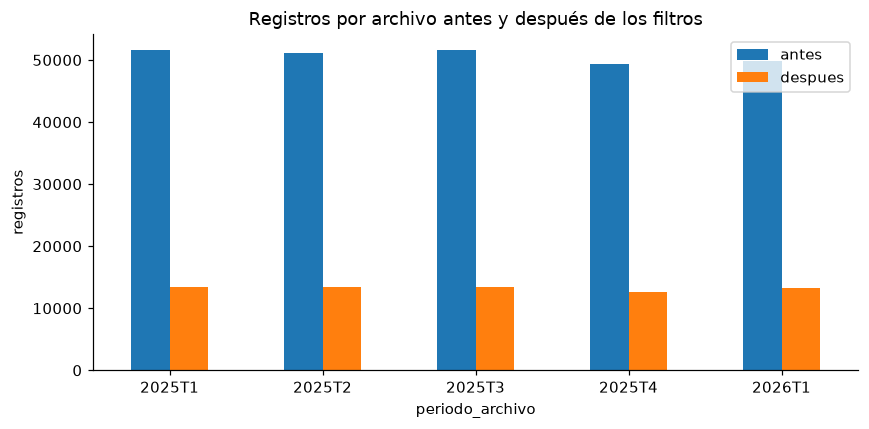

In [13]:
por_archivo = pd.concat([calidad.resumen_por_archivo(embudo_2025), calidad.resumen_por_archivo(embudo_2026)])
por_archivo = por_archivo[por_archivo["periodo_archivo"] != "TOTAL"].reset_index(drop=True)
display(por_archivo)

ax = por_archivo.set_index("periodo_archivo")[["antes", "despues"]].plot.bar(figsize=(8, 4), rot=0)
ax.set_ylabel("registros")
ax.set_title("Registros por archivo antes y después de los filtros")
plt.tight_layout()
plt.savefig(config.FIGURES / "01_registros_por_archivo.png", dpi=120)
plt.show()

In [14]:
total = embudo_2025[embudo_2025["periodo_archivo"] == "TOTAL"].set_index("paso")
inicial = int(total.loc["registros originales", "restantes"])
final = int(total["restantes"].iloc[-1])
mayor = total.drop("registros originales")["excluidos"].idxmax()
print(f"2025: {inicial:,} registros originales -> {final:,} en la población analítica ({100 * final / inicial:.1f} %).")
print(f"El paso que más registros excluye es: '{mayor}' ({int(total.loc[mayor, 'excluidos']):,}).")

2025: 203,676 registros originales -> 53,025 en la población analítica (26.0 %).
El paso que más registros excluye es: 'edad finita y >= 15' (62,886).


### Interpretación del embudo

Los tres primeros pasos definen la población analítica. En 2025 se pasa de 203,676 registros a 140,790 con 15 años o más (−62,886), luego a 88,222 ocupados (−52,568) y a **53,025 asalariados** (−35,197). Son **cambios de población**, no errores de datos: la base cubre a todas las personas del hogar y solo una parte está ocupada y es asalariada.

Los pasos de salario, antigüedad y horas **no excluyen ningún registro**, ni en 2025 ni en 2026: todos los asalariados tienen un salario positivo registrado, una antigüedad válida y horas habituales entre 1 y 168. Los faltantes de esas variables (sección 4) pertenecen a personas a quienes la pregunta no corresponde.

La población analítica es el **26.0 %** de los registros de 2025 (entre 25.7 % y 26.4 % según el archivo) y el 26.6 % de 2026 (13,258 registros). Como el orden es fijo, cada registro se cuenta una sola vez, en el primer criterio que no cumple.

Al exigir un salario positivo registrado, los resultados se refieren específicamente a **asalariados con salario positivo registrado**.

## 7. Unicidad de `periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA`

Se comprueba, sobre todos los registros originales seleccionados, si la combinación es única. Si hay claves repetidas se investiga si son **repeticiones exactas** (todas las columnas seleccionadas iguales) o **registros en conflicto** (mismos identificadores con valores distintos). No se usa `dropDuplicates()`.

In [15]:
unicidad = pd.DataFrame({
    "2025": calidad.resumen_unicidad(df_2025),
    "2026": calidad.resumen_unicidad(df_2026),
})
unicidad

,2025,2026
registros,203676,49843
claves_distintas,203676,49843
claves_duplicadas,0,0
filas_en_claves_duplicadas,0,0


In [16]:
detalle_2025 = calidad.detalle_duplicados(df_2025)
detalle_2026 = calidad.detalle_duplicados(df_2026)
tipos = (detalle_2025.withColumn("conjunto", F.lit("2025"))
         .unionByName(detalle_2026.withColumn("conjunto", F.lit("2026")))
         .groupBy("conjunto", "tipo").agg(F.count(F.lit(1)).alias("claves"), F.sum("filas").alias("filas")))
tipos.orderBy("conjunto", "tipo").toPandas()

,conjunto,tipo,claves,filas


In [17]:
n_dup = unicidad.loc["claves_duplicadas", "2025"]
if n_dup == 0:
    print("2025: no hay claves repetidas; cada (periodo_archivo, NUM_HOGAR, NUM_PERSONA) aparece una sola vez.")
else:
    print(f"2025: {n_dup:,} claves repetidas. Columnas que difieren dentro de esas claves:")
    display(calidad.columnas_en_conflicto(df_2025).query("claves_con_diferencia > 0"))
    print("Ejemplos de claves repetidas:")
    display(detalle_2025.orderBy(F.desc("versiones"), F.desc("filas")).limit(10).toPandas())

2025: no hay claves repetidas; cada (periodo_archivo, NUM_HOGAR, NUM_PERSONA) aparece una sola vez.


### Interpretación de la unicidad

**No hay claves repetidas.** En 2025, las 203,676 filas tienen 203,676 combinaciones distintas de `periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA`; en 2026, las 49,843 filas tienen 49,843. No hay repeticiones exactas ni registros en conflicto, así que no fue necesario eliminar nada y no se usó `dropDuplicates()`.

Si hubiera aparecido una clave repetida, se habría distinguido entre una **repetición exacta** (el mismo registro llegó dos veces) y un **conflicto** (dos versiones distintas de la misma persona en el mismo corte, sin forma de saber cuál es la correcta sin consultar la fuente). La verificación queda en el notebook como evidencia.

Como `periodo_archivo` forma parte de la clave, una misma persona observada en dos periodos **no** se considera repetida (ver pregunta 3).

## 8. Conjuntos preparados en Parquet

Se aplican los filtros de la sección 6, se validan las categóricas (`DESCONOCIDO` para ausentes o no reconocidos) y se guardan por separado la población de 2025 y la de 2026. La antigüedad queda en años. Para 2026 se aplican **exactamente las mismas reglas** que para 2025.

In [18]:
prep_2025 = calidad.preparar(df_2025)
prep_2026 = calidad.preparar(df_2026)

ruta_2025 = calidad.guardar_preparado(prep_2025, "personas_2025")
ruta_2026 = calidad.guardar_preparado(prep_2026, "personas_2026")

leido_2025 = spark.read.parquet(str(ruta_2025))
leido_2026 = spark.read.parquet(str(ruta_2026))
print("personas_2025:", leido_2025.count(), "registros |", ruta_2025.name)
print("personas_2026:", leido_2026.count(), "registros |", ruta_2026.name)
leido_2025.printSchema()

personas_2025: 53025 registros | personas_2025.parquet
personas_2026: 13258 registros | personas_2026.parquet
root
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)



In [19]:
leido_2025.limit(5).toPandas()

,periodo_archivo,anio_archivo,trimestre_calendario,archivo_origen,NUM_HOGAR,NUM_PERSONA,FACTOR,ANIO,TRIMESTRE,salario_mensual,edad,antiguedad,horas_semanales,nivel_educativo,categoria_ocupacional,dominio
0,2025T2,2025,2,ENEIC_2025T2.xlsx,2781,4,175.00,2025,3,"1,608.00",31.00,3.00,6.00,5,2,2
1,2025T2,2025,2,ENEIC_2025T2.xlsx,2781,3,175.00,2025,3,"5,000.00",23.00,3.00,64.00,5,2,2
2,2025T2,2025,2,ENEIC_2025T2.xlsx,16023,1,228.00,2025,3,"2,400.00",56.00,0.17,46.00,2,2,1
3,2025T2,2025,2,ENEIC_2025T2.xlsx,17491,3,356.00,2025,3,"2,400.00",23.00,0.08,48.00,0,2,2
4,2025T2,2025,2,ENEIC_2025T2.xlsx,17491,2,356.00,2025,3,"2,000.00",38.00,0.17,42.00,0,4,2


In [20]:
desconocidos = pd.DataFrame({
    conjunto: {c: leido.filter(F.col(c) == config.DESCONOCIDO).count() for c in config.CATEGORICAS}
    for conjunto, leido in {"2025": leido_2025, "2026": leido_2026}.items()
})
desconocidos.index.name = "registros con DESCONOCIDO"
desconocidos

,2025,2026
registros con DESCONOCIDO,,
nivel_educativo,0,0
categoria_ocupacional,0,0
dominio,0,0


## 9. Preguntas de la sección

**1. ¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**

Porque tiene una estructura distinta: 302 columnas frente a las 270 de los demás archivos, y las columnas adicionales alteran las posiciones (la tabla de la sección 1 muestra cuántas columnas quedan en otra posición). Apilar por posición pondría en una misma columna variables con significados diferentes, por ejemplo edad con horas o el salario con un código, sin error visible, y con tipos mezclados. `unionByName` empareja cada columna por su nombre, así que solo se combinan variables equivalentes y el orden o las columnas sobrantes dejan de importar.

**2. ¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**

El primero es un faltante estructural: la pregunta no se le hace a esa persona por el flujo del cuestionario (por ejemplo, el salario de la ocupación principal no se pregunta a quien no trabaja). No es un error y no debe imputarse ni tratarse como pérdida de información. El segundo ocurre cuando la persona sí debía responder y el dato no quedó registrado (no respondió, no supo o hubo un error de captura); ese sí reduce la calidad del dato. Se distinguen mirando el flujo del cuestionario y la población a la que aplica la pregunta: por eso primero se define la población analítica y solo entonces se cuentan los faltantes que quedan. En este trabajo el salario ausente entre asalariados se excluye y no se imputa, y las categóricas ausentes o no reconocidas se marcan como `DESCONOCIDO`, sin convertirlas a cero (el código educativo 0 significa "ninguno").

**3. ¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**

Porque la encuesta tiene un diseño longitudinal con rotación: la misma persona puede ser entrevistada en más de un trimestre y cada aparición es una observación válida de un período distinto. Por eso la clave de unicidad incluye `periodo_archivo`. Eliminarlas descartaría información legítima, cambiaría la composición de cada trimestre y alteraría las comparaciones entre períodos. Quedan, eso sí, dos consecuencias que se deben recordar: el número de filas no es el número de personas distintas y las observaciones repetidas de una misma persona no son independientes entre sí.

**4. ¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**

Porque es una muestra, no un censo: cada registro representa a un número distinto de personas según su `FACTOR` de expansión, y aquí los análisis son no ponderados. Además, la base filtrada solo incluye personas de 15 años o más, ocupadas, asalariadas y con salario positivo registrado, con lo que quedan fuera los trabajadores independientes, los patronos, los no remunerados y quienes no tienen salario registrado. Y hay personas que aparecen en más de un período. Los resultados describen los registros analizados; para estimar a la población se ponderaría con `FACTOR` y se consideraría el diseño muestral.

In [21]:
for d in list(dfs.values()) + [df_2025]:
    d.unpersist()

# Parte 2 · Estadística descriptiva, exploración y correlaciones

Se trabaja con la población analítica de **2025** (`data/processed/personas_2025.parquet`): personas de 15 años o más, ocupadas, asalariadas y con salario positivo registrado.

- Las estadísticas, los percentiles y las correlaciones se calculan con **todos** los registros de 2025 en Spark.
- A pandas solo pasan tablas agregadas (conteos, histogramas ya agrupados).
- Los resultados describen los registros analizados; no son estimaciones oficiales de la población guatemalteca (análisis no ponderado).

In [22]:
df = spark.read.parquet(str(config.DATA_PROCESSED / "personas_2025.parquet")).persist()
print("Registros de la población analítica 2025:", f"{df.count():,}")

Registros de la población analítica 2025: 53,025


## 1. Estadística descriptiva

Cantidad de observaciones, media, mediana, desviación estándar, mínimo, máximo y percentiles 25, 75 y 95 de las cuatro variables numéricas. Los percentiles son exactos, no aproximados.

In [23]:
desc = exploracion.descriptivas(df)
desc.index = [exploracion.ETIQUETAS[v] for v in desc.index]
desc.to_csv(config.TABLES / "02_descriptivas_2025.csv")
desc

,n,media,mediana,desv_estandar,minimo,maximo,p25,p75,p95
Salario mensual (Q),53025,"3,421.68","3,000.00","2,902.11",1.00,"99,000.00","1,800.00","4,000.00","8,000.00"
Edad (años),53025,35.19,33.00,13.52,15.00,89.00,24.00,44.00,61.00
Antigüedad (años),53025,5.56,2.00,7.83,0.00,70.00,0.50,7.00,22.00
Horas semanales,53025,46.31,45.00,18.63,1.00,126.00,40.00,55.00,80.00


In [24]:
d = exploracion.descriptivas(df)
s = d.loc["salario_mensual"]
print(f"Salario: mediana Q{s['mediana']:,.0f}, media Q{s['media']:,.0f}, P95 Q{s['p95']:,.0f}, máximo Q{s['maximo']:,.0f}.")
print(f"El 5 % con mayores salarios gana más de Q{s['p95']:,.0f}; el máximo es {s['maximo'] / s['mediana']:.1f} veces la mediana.")
for v in ["edad", "antiguedad", "horas_semanales"]:
    r = d.loc[v]
    print(f"{exploracion.ETIQUETAS[v]}: mediana {r['mediana']:.1f}, rango intercuartílico {r['p25']:.1f} a {r['p75']:.1f}, máximo {r['maximo']:.1f}.")

Salario: mediana Q3,000, media Q3,422, P95 Q8,000, máximo Q99,000.
El 5 % con mayores salarios gana más de Q8,000; el máximo es 33.0 veces la mediana.
Edad (años): mediana 33.0, rango intercuartílico 24.0 a 44.0, máximo 89.0.
Antigüedad (años): mediana 2.0, rango intercuartílico 0.5 a 7.0, máximo 70.0.
Horas semanales: mediana 45.0, rango intercuartílico 40.0 a 55.0, máximo 126.0.


**Interpretación.** Los 53,025 registros de 2025 tienen un salario mediano de **Q3,000** y medio de **Q3,422**; la mitad central gana entre Q1,800 y Q4,000 y el 5 % más alto supera los Q8,000. El máximo (Q99,000) es 33 veces la mediana y la desviación estándar (Q2,902) es casi tan grande como la media: la dispersión viene de una cola de salarios altos. La edad mediana es 33 años (24 a 44). La antigüedad es muy asimétrica: mediana de 2 años frente a una media de 5.6 y un máximo de 70, es decir, la mayoría lleva poco tiempo en su empleo y unos pocos llevan décadas. La jornada mediana es de 45 horas (40 a 55), con un 5 % que trabaja 80 horas o más.

## 2. Distribución de los registros por categoría ocupacional, nivel educativo y dominio

Los códigos se muestran tal como vienen en las bases; la categoría ocupacional se rotula con su significado.

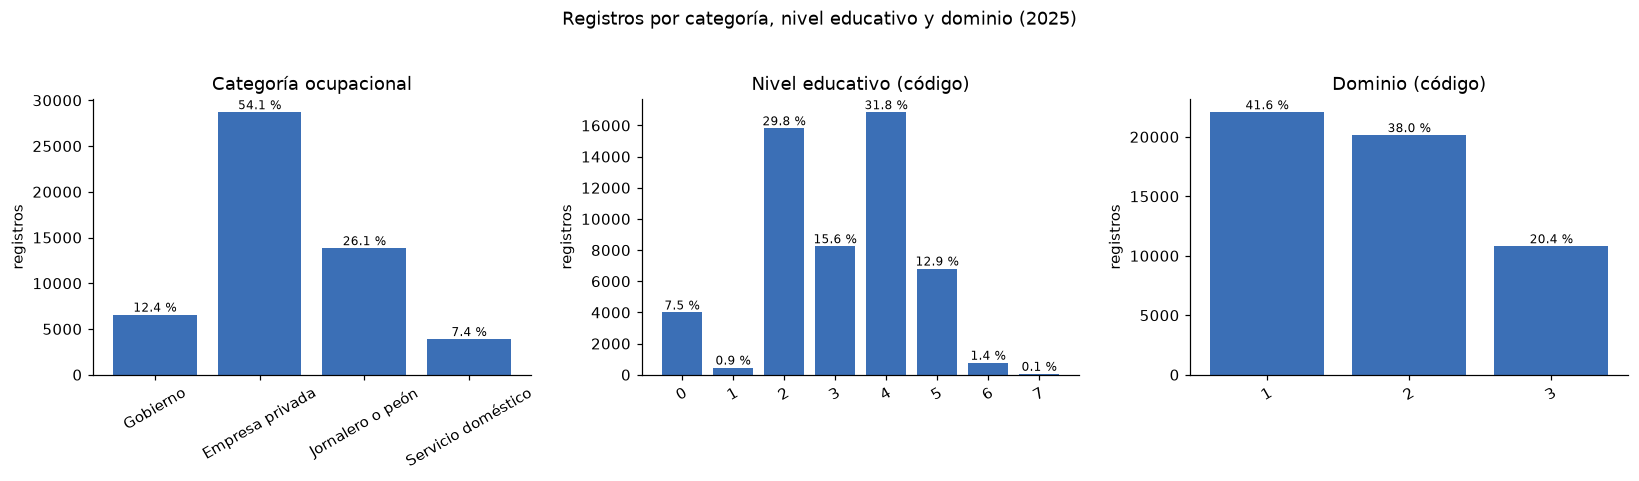

In [25]:
CATEGORIAS = {"1": "Gobierno", "2": "Empresa privada", "3": "Jornalero o peón", "4": "Servicio doméstico"}

def rotular(tabla, mapa=None, prefijo=""):
    t = tabla.copy()
    t["etiqueta"] = [mapa.get(c, c) if mapa else (c if c == config.DESCONOCIDO else f"{prefijo}{c}") for c in t["categoria"]]
    return t

conteos = {
    "Categoría ocupacional": rotular(exploracion.conteo_categorias(df, "categoria_ocupacional"), CATEGORIAS),
    "Nivel educativo (código)": rotular(exploracion.conteo_categorias(df, "nivel_educativo")),
    "Dominio (código)": rotular(exploracion.conteo_categorias(df, "dominio")),
}

fig, ejes = plt.subplots(1, 3, figsize=(15, 4.2))
for eje, (titulo, t) in zip(ejes, conteos.items()):
    barras = eje.bar(t["etiqueta"], t["registros"], color="#3B6FB6")
    for b, p in zip(barras, t["porcentaje"]):
        eje.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{p:.1f} %", ha="center", va="bottom", fontsize=8)
    eje.set_title(titulo)
    eje.set_ylabel("registros")
    eje.tick_params(axis="x", rotation=30)
fig.suptitle("Registros por categoría, nivel educativo y dominio (2025)", y=1.03)
plt.tight_layout()
plt.savefig(config.FIGURES / "02_distribucion_categorias.png", dpi=120, bbox_inches="tight")
plt.show()

In [26]:
for titulo, t in conteos.items():
    mayor = t.loc[t["registros"].idxmax()]
    menor = t.loc[t["registros"].idxmin()]
    print(f"{titulo}: la categoría más frecuente es '{mayor['etiqueta']}' ({mayor['porcentaje']:.1f} %) y la menos frecuente '{menor['etiqueta']}' ({menor['porcentaje']:.1f} %).")
pd.concat({k: v[["etiqueta", "registros", "porcentaje"]].set_index("etiqueta") for k, v in conteos.items()})

Categoría ocupacional: la categoría más frecuente es 'Empresa privada' (54.1 %) y la menos frecuente 'Servicio doméstico' (7.4 %).
Nivel educativo (código): la categoría más frecuente es '4' (31.8 %) y la menos frecuente '7' (0.1 %).
Dominio (código): la categoría más frecuente es '1' (41.6 %) y la menos frecuente '3' (20.4 %).


registros  porcentaje
                         etiqueta                                 
Categoría ocupacional    Gobierno                 6575       12.40
                         Empresa privada         28702       54.13
                         Jornalero o peón        13842       26.10
                         Servicio doméstico       3906        7.37
Nivel educativo (código) 0                        3995        7.53
                         1                         459        0.87
                         2                       15822       29.84
                         3                        8249       15.56
                         4                       16851       31.78
                         5                        6818       12.86
                         6                         771        1.45
                         7                          60        0.11
Dominio (código)         1                       22072       41.63
                         2                       20146       37.99
                         3                       10807       20.38

**Interpretación.** Más de la mitad de los registros son empleados de **empresa privada (54.1 %)**, seguidos por jornaleros o peones (26.1 %), empleados de gobierno (12.4 %) y servicio doméstico (7.4 %). En educación, los códigos **4 (31.8 %) y 2 (29.8 %)** concentran más de 60 % de los registros; los códigos 6 (1.5 %), 1 (0.9 %) y 7 (0.1 %, solo 60 registros) son muy pequeños, por lo que sus medianas son poco estables. El dominio 1 reúne 41.6 % de los registros, el 2 el 38.0 % y el 3 el 20.4 %. Después de los filtros no quedan categorías `DESCONOCIDO`. Estas proporciones describen la muestra filtrada sin ponderar, no a todos los trabajadores del país.

## 3. Forma de la distribución del salario

El histograma se calcula en Spark (los conteos por intervalo salen de todos los registros). Se muestra en **quetzales** y en **escala logarítmica (log10 del salario)**. La escala logarítmica solo se usa para visualizar; el objetivo del modelado sigue siendo el salario original en quetzales.

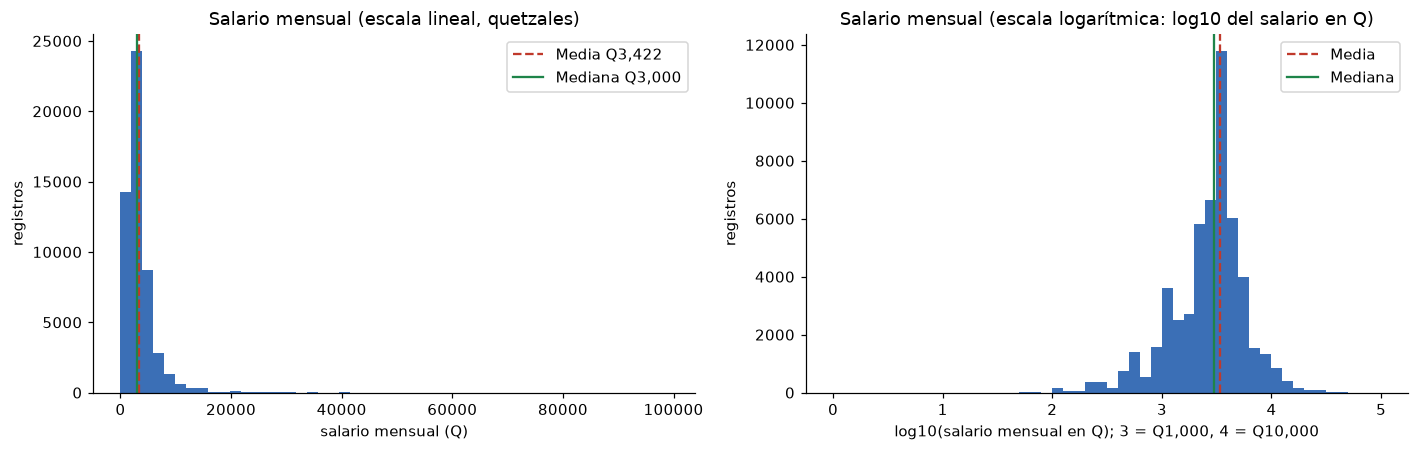

In [27]:
h_lin = exploracion.histograma(df, "salario_mensual", bins=50)
h_log = exploracion.histograma(df, "salario_mensual", bins=50, log10=True)
sal = exploracion.asimetria(df, "salario_mensual")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.2))
a.bar(h_lin["desde"], h_lin["registros"], width=(h_lin["hasta"] - h_lin["desde"]).iloc[0], align="edge", color="#3B6FB6")
a.axvline(sal["media"], color="#C0392B", ls="--", label=f"Media Q{sal['media']:,.0f}")
a.axvline(sal["mediana"], color="#1E8449", ls="-", label=f"Mediana Q{sal['mediana']:,.0f}")
a.set_title("Salario mensual (escala lineal, quetzales)")
a.set_xlabel("salario mensual (Q)")
a.set_ylabel("registros")
a.legend()

b.bar(h_log["desde"], h_log["registros"], width=(h_log["hasta"] - h_log["desde"]).iloc[0], align="edge", color="#3B6FB6")
b.axvline(np.log10(sal["media"]), color="#C0392B", ls="--", label="Media")
b.axvline(np.log10(sal["mediana"]), color="#1E8449", ls="-", label="Mediana")
b.set_title("Salario mensual (escala logarítmica: log10 del salario en Q)")
b.set_xlabel("log10(salario mensual en Q); 3 = Q1,000, 4 = Q10,000")
b.set_ylabel("registros")
b.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / "02_histograma_salario.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
print(f"Coeficiente de asimetría (skewness) del salario: {sal['asimetria']:.2f}")
print(f"Media Q{sal['media']:,.0f} vs. mediana Q{sal['mediana']:,.0f}: la media es {100 * (sal['media'] / sal['mediana'] - 1):+.1f} % respecto a la mediana (diferencia Q{sal['media'] - sal['mediana']:,.0f}).")
if sal["asimetria"] > 0.5:
    print("Conclusión: distribución asimétrica con cola larga hacia salarios altos (asimetría positiva).")
elif sal["asimetria"] < -0.5:
    print("Conclusión: distribución asimétrica con cola hacia salarios bajos (asimetría negativa).")
else:
    print("Conclusión: distribución aproximadamente simétrica.")

Coeficiente de asimetría (skewness) del salario: 6.00
Media Q3,422 vs. mediana Q3,000: la media es +14.1 % respecto a la mediana (diferencia Q422).
Conclusión: distribución asimétrica con cola larga hacia salarios altos (asimetría positiva).


**Interpretación.**

- **¿Simétrica o asimétrica?** Claramente **asimétrica a la derecha**: el coeficiente de asimetría es **6.0** y el histograma en quetzales muestra casi todos los registros por debajo de Q10,000 con una cola larga hasta Q99,000.
- **Media frente a mediana.** La media (Q3,422) supera a la mediana (Q3,000) en **Q422 (+14.1 %)**, porque los salarios altos la arrastran hacia arriba. La mediana representa mejor el salario típico.
- **Escala logarítmica.** En log10 la distribución se parece mucho más a una campana centrada cerca de 3.5 (unos Q3,000): la asimetría se debe sobre todo a que los salarios crecen de forma multiplicativa. Solo se usa para visualizar; el modelado usa el salario en quetzales.
- Los salarios altos y bajos **no se eliminaron**; su influencia se discutirá en el modelado (un modelo que minimiza el error cuadrático será sensible a esa cola).

## 4. Salario mediano por nivel educativo y por categoría ocupacional

Se usa la mediana (más robusta que la media) y se anota el número de registros de cada grupo.

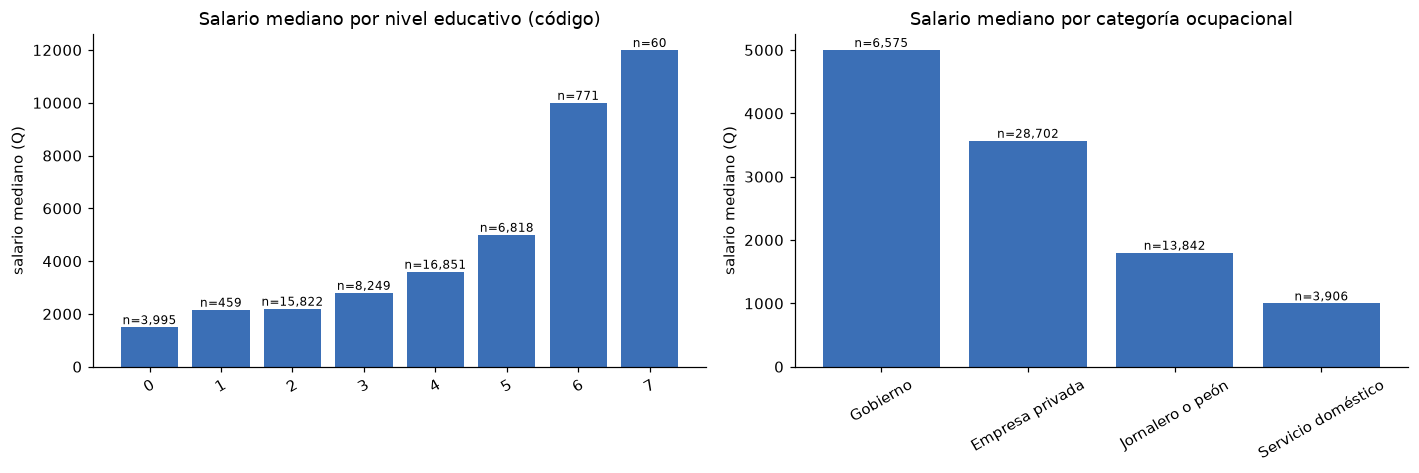

etiqueta  registros  salario_mediano  salario_medio
nivel_educativo       0                   0       3995         1,500.00       1,767.09
                      1                   1        459         2,160.00       2,241.90
                      2                   2      15822         2,200.00       2,307.96
                      3                   3       8249         2,800.00       2,730.20
                      4                   4      16851         3,600.00       3,796.41
                      5                   5       6818         5,000.00       5,965.30
                      6                   6        771        10,000.00      11,409.27
                      7                   7         60        12,000.00      14,452.27
categoria_ocupacional 0            Gobierno       6575         5,000.00       5,971.53
                      1     Empresa privada      28702         3,567.50       3,875.14
                      2    Jornalero o peón      13842         1,800.00       1,878.61
                      3  Servicio doméstico       3906         1,000.00       1,265.74
dominio               0                   1      22072         3,700.00       4,190.89
                      1                   2      20146         2,880.00       3,131.06
                      2                   3      10807         2,000.00       2,392.43

In [29]:
por_educ = rotular(exploracion.salario_por_grupo(df, "nivel_educativo"))
por_cat = rotular(exploracion.salario_por_grupo(df, "categoria_ocupacional"), CATEGORIAS)
por_dom = rotular(exploracion.salario_por_grupo(df, "dominio"))

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.4))
for eje, t, titulo in [(ejes[0], por_educ, "Nivel educativo (código)"), (ejes[1], por_cat, "Categoría ocupacional")]:
    barras = eje.bar(t["etiqueta"], t["salario_mediano"], color="#3B6FB6")
    for b, n in zip(barras, t["registros"]):
        eje.text(b.get_x() + b.get_width() / 2, b.get_height(), f"n={n:,}", ha="center", va="bottom", fontsize=8)
    eje.set_title(f"Salario mediano por {titulo.lower()}")
    eje.set_ylabel("salario mediano (Q)")
    eje.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(config.FIGURES / "02_salario_mediano_grupos.png", dpi=120, bbox_inches="tight")
plt.show()

tabla_grupos = pd.concat({
    "nivel_educativo": por_educ, "categoria_ocupacional": por_cat, "dominio": por_dom,
})[["etiqueta", "registros", "salario_mediano", "salario_medio"]]
tabla_grupos.to_csv(config.TABLES / "02_salario_por_grupo_2025.csv")
tabla_grupos

In [30]:
def rango(t, nombre):
    alto, bajo = t.loc[t["salario_mediano"].idxmax()], t.loc[t["salario_mediano"].idxmin()]
    print(f"{nombre}: mediana más alta en '{alto['etiqueta']}' (Q{alto['salario_mediano']:,.0f}, n={alto['registros']:,}) y más baja en '{bajo['etiqueta']}' (Q{bajo['salario_mediano']:,.0f}, n={bajo['registros']:,}); razón {alto['salario_mediano'] / bajo['salario_mediano']:.1f}.")

rango(por_educ, "Nivel educativo")
rango(por_cat, "Categoría ocupacional")
rango(por_dom, "Dominio")

Nivel educativo: mediana más alta en '7' (Q12,000, n=60) y más baja en '0' (Q1,500, n=3,995); razón 8.0.
Categoría ocupacional: mediana más alta en 'Gobierno' (Q5,000, n=6,575) y más baja en 'Servicio doméstico' (Q1,000, n=3,906); razón 5.0.
Dominio: mediana más alta en '1' (Q3,700, n=22,072) y más baja en '3' (Q2,000, n=10,807); razón 1.9.


**Interpretación.** El salario mediano **crece con el nivel educativo** de forma casi continua: Q1,500 en el código 0 (ninguno), Q2,200 en el 2, Q3,600 en el 4, Q5,000 en el 5 y Q10,000–Q12,000 en los códigos 6 y 7 (estos últimos con pocos registros: 771 y 60). Entre categorías ocupacionales, el **empleo de gobierno** tiene la mediana más alta (Q5,000), seguido de empresa privada (Q3,568), jornaleros (Q1,800) y **servicio doméstico** (Q1,000): la razón entre el extremo alto y el bajo es de 5 a 1. Por dominio, la mediana va de Q3,700 (dominio 1) a Q2,000 (dominio 3). Son **asociaciones descriptivas**: no muestran que estudiar más *cause* un salario mayor ni indican cuánto debería ganar una persona, y las variables se mezclan entre sí (el empleo de gobierno concentra más educación).

## 5. Tamaño de la muestra y salario mediano por trimestre

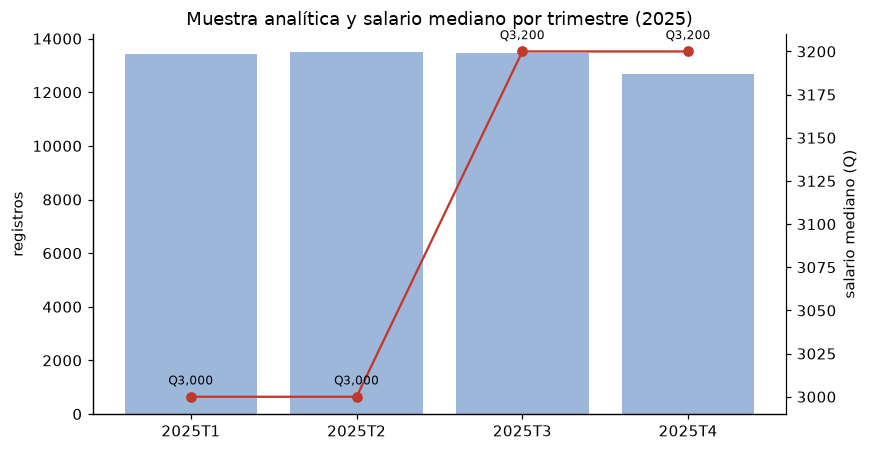

,periodo_archivo,registros,salario_mediano,salario_medio
0,2025T1,13419,"3,000.00","3,315.63"
1,2025T2,13492,"3,000.00","3,364.57"
2,2025T3,13450,"3,200.00","3,469.07"
3,2025T4,12664,"3,200.00","3,544.57"


In [31]:
trim = exploracion.resumen_por_trimestre(df)
trim.to_csv(config.TABLES / "02_resumen_trimestre_2025.csv", index=False)

fig, a = plt.subplots(figsize=(8, 4.2))
a.bar(trim["periodo_archivo"], trim["registros"], color="#9DB7DB", label="Registros analíticos")
a.set_ylabel("registros")
b = a.twinx()
b.plot(trim["periodo_archivo"], trim["salario_mediano"], color="#C0392B", marker="o", label="Salario mediano")
b.set_ylabel("salario mediano (Q)")
b.spines["right"].set_visible(True)
a.set_title("Muestra analítica y salario mediano por trimestre (2025)")
for x, y in zip(trim["periodo_archivo"], trim["salario_mediano"]):
    b.annotate(f"Q{y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES / "02_muestra_y_mediana_trimestre.png", dpi=120, bbox_inches="tight")
plt.show()
trim

In [32]:
variacion_n = 100 * (trim["registros"].max() / trim["registros"].min() - 1)
variacion_m = 100 * (trim["salario_mediano"].max() / trim["salario_mediano"].min() - 1)
print(f"El tamaño de la muestra varía {variacion_n:.1f} % entre el trimestre más pequeño y el más grande.")
print(f"El salario mediano varía {variacion_m:.1f} % entre el trimestre más bajo y el más alto.")

El tamaño de la muestra varía 6.5 % entre el trimestre más pequeño y el más grande.
El salario mediano varía 6.7 % entre el trimestre más bajo y el más alto.


**Interpretación.** El tamaño de la muestra analítica es estable: entre 12,664 (2025T4) y 13,492 (2025T2) registros, una variación de 6.5 %. El salario mediano es de Q3,000 en los dos primeros trimestres y de **Q3,200** en el tercero y el cuarto (+6.7 %), y la media sube de Q3,316 a Q3,545. Hay un leve aumento en la segunda mitad del año, pero es pequeño, no se ha medido su incertidumbre y parte de las personas se repite entre trimestres, así que no permite concluir que los salarios cambiaron.

## 6. Correlaciones entre variables numéricas

Correlación de Pearson calculada con `VectorAssembler` y `Correlation.corr` de `pyspark.ml.stat`, sobre **todos** los registros elegibles de 2025.

In [33]:
corr = exploracion.matriz_correlacion(df)
etiquetas = [exploracion.ETIQUETAS[v] for v in corr.columns]
corr_rotulada = corr.set_axis(etiquetas, axis=0).set_axis(etiquetas, axis=1)
corr_rotulada.to_csv(config.TABLES / "02_correlacion_2025.csv")
corr_rotulada.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)

,Salario mensual (Q),Edad (años),Antigüedad (años),Horas semanales
Salario mensual (Q),1.000,0.147,0.180,0.076
Edad (años),0.147,1.000,0.487,-0.105
Antigüedad (años),0.180,0.487,1.000,-0.062
Horas semanales,0.076,-0.105,-0.062,1.000


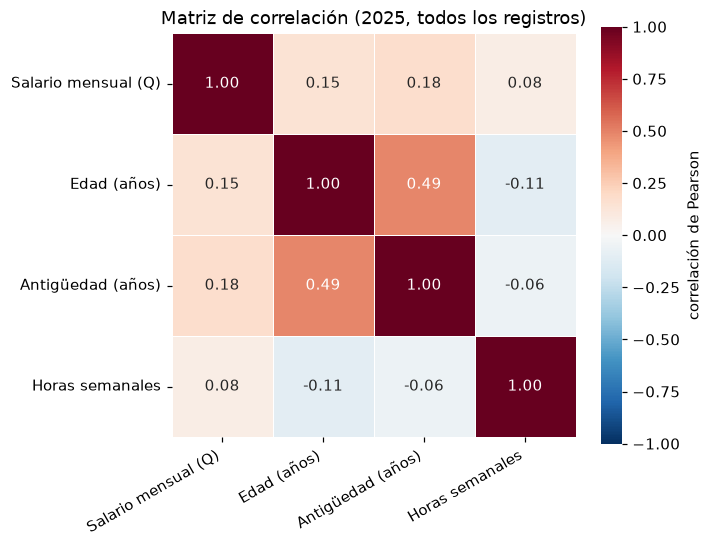

In [34]:
fig, eje = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr_rotulada, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            linewidths=.5, cbar_kws={"label": "correlación de Pearson"}, ax=eje)
eje.set_title("Matriz de correlación (2025, todos los registros)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(config.FIGURES / "02_mapa_calor_correlacion.png", dpi=120, bbox_inches="tight")
plt.show()

In [35]:
con_salario = corr["salario_mensual"].drop("salario_mensual").sort_values(key=np.abs, ascending=False)
for v, r in con_salario.items():
    fuerza = "muy débil" if abs(r) < .1 else "débil" if abs(r) < .3 else "moderada" if abs(r) < .5 else "fuerte"
    print(f"Salario vs. {exploracion.ETIQUETAS[v]}: r = {r:+.3f} ({fuerza}, r² = {r ** 2:.3f})")
print(f"\nMayor asociación lineal con el salario: {exploracion.ETIQUETAS[con_salario.index[0]]}.")
r_ea = corr.loc["edad", "antiguedad"]
print(f"Edad vs. antigüedad: r = {r_ea:+.3f}")

Salario vs. Antigüedad (años): r = +0.180 (débil, r² = 0.032)
Salario vs. Edad (años): r = +0.147 (débil, r² = 0.022)
Salario vs. Horas semanales: r = +0.076 (muy débil, r² = 0.006)

Mayor asociación lineal con el salario: Antigüedad (años).
Edad vs. antigüedad: r = +0.487


**Interpretación.**

- **Asociación lineal con el salario.** Las tres correlaciones son **débiles**: antigüedad **r = 0.18** (la mayor), edad r = 0.15 y horas r = 0.08. La antigüedad sola explica linealmente apenas 3.2 % de la variación del salario (r² = 0.032). Ninguna variable numérica por sí sola explica bien el salario, por eso los modelos incluyen además nivel educativo, categoría ocupacional y dominio, que en la sección 4 mostraron diferencias de mediana mucho mayores.
- **Edad y antigüedad.** Sí hay relación: **r = 0.49**, positiva y moderada. Quienes tienen más edad han tenido más tiempo para acumular antigüedad, pero los cambios de empleo la debilitan (hay personas mayores con poca antigüedad). No es tan alta como para que una variable sustituya a la otra.
- **Precauciones.** Pearson mide solo asociación **lineal** y es sensible a valores extremos, y el salario tiene cola derecha; una relación no lineal puede quedar subestimada. Las correlaciones no demuestran causalidad, y las observaciones repetidas de una misma persona no son independientes.

In [36]:
_ = df.unpersist()

# Parte 3 · Segmentación de perfiles mediante KMeans

Se busca responder: **¿qué perfiles de trabajadores asalariados pueden identificarse según su edad, antigüedad y jornada habitual?**

- Población: registros de **2025** de `data/processed/personas_2025.parquet` (15 años o más, ocupados, asalariados y con salario positivo registrado).
- El ajuste del escalador, de KMeans y todas las métricas (silhouette, WSSSE, tamaños y perfiles) se calculan con **todos** los registros de 2025 en Spark. A pandas pasan solo tablas agregadas y una muestra de hasta 5,000 registros para dibujar.
- La segmentación es **no ponderada**: describe los registros analizados, no a la población guatemalteca. Una misma persona puede aparecer en más de un trimestre.
- 2026 no se usa en esta sección.

In [37]:
pob = segmentacion.agregar_salario_log(
    spark.read.parquet(str(config.DATA_PROCESSED / "personas_2025.parquet"))
).persist()
print("Registros de la población analítica 2025:", f"{pob.count():,}")

Registros de la población analítica 2025: 53,025


## 1. Selección de variables: ¿vale la pena incluir el salario?

**Variables del perfil:** `edad`, `antiguedad` y `horas_semanales`. Son numéricas continuas, describen la situación laboral de la persona y no dependen del salario.

**Variables que no entran en KMeans:**

- Nivel educativo, categoría ocupacional y dominio son **códigos**, no magnitudes: la distancia euclidiana entre "código 1" y "código 4" no tiene significado, y convertirlas a variables binarias haría que dominaran la distancia. Se usan **después** para describir cada perfil.
- Identificadores, `FACTOR` y `TRIMESTRE` no describen a la persona.

**¿Y el salario?** Se evalúan dos especificaciones con el mismo procedimiento:

| Especificación | Variables |
|---|---|
| `sin_salario` | edad, antigüedad, horas semanales |
| `con_salario` | las tres anteriores + `log10(salario)` |

Cuando se incluye, el salario entra en **log10** solo para la segmentación: tiene una cola derecha muy larga (sección 02) y, en quetzales, unos pocos salarios extremos acapararían un cluster propio. El objetivo del modelado sigue siendo el salario en quetzales.

Hay además un argumento de fondo: el salario es la variable que se intenta **explicar** en la segunda parte. Si define los grupos, los perfiles quedan construidos en parte con la respuesta y ya no sirven para preguntar si perfiles laborales distintos tienen salarios distintos. Por eso la especificación principal es `sin_salario`. La especificación `con_salario` se usa como contraste para ver qué cambia si se incluye.

Todas las variables se **estandarizan** (media 0, desviación 1) con `StandardScaler` dentro del pipeline. Sin estandarizar, las horas (hasta 168) y la edad pesarían más que la antigüedad solo por sus unidades.

In [38]:
resumen_vars = pob.select(*segmentacion.VARIABLES_CON_SALARIO).summary("mean", "stddev", "min", "max").toPandas().set_index("summary").astype(float).T
resumen_vars.index = [segmentacion.ETIQUETAS[v] for v in resumen_vars.index]
resumen_vars

summary,mean,stddev,min,max
Edad (años),35.19,13.52,15.00,89.00
Antigüedad (años),5.56,7.83,0.00,70.00
Horas semanales,46.31,18.63,1.00,126.00
log10(salario),3.42,0.34,0.00,5.00


**Lectura.** Las variables tienen escalas muy distintas: sin estandarizar, la variable con mayor desviación estándar dominaría la distancia euclidiana de KMeans. Después del `StandardScaler` todas quedan con desviación 1 y pesan lo mismo.

## 2. Elección del número de clusters (K = 2, 3, 4 y 5)

Para cada especificación se ajusta el pipeline `VectorAssembler → StandardScaler → KMeans` con semilla fija (`config.SEMILLA`) y se calcula:

- **Silhouette** (distancia euclidiana al cuadrado, `ClusteringEvaluator`): mide qué tan cerca está cada registro de su cluster frente al cluster vecino. Va de −1 a 1; más alto indica grupos más separados.
- **WSSSE** (suma de distancias al cuadrado dentro de los clusters): siempre baja al aumentar K, por lo que se mira dónde deja de bajar mucho (codo).
- **Tamaño del cluster más pequeño** (en % de registros).

**Criterio del grupo: codo del WSSSE, confirmado con silhouette.**

1. Se descartan los K cuyo cluster más pequeño tiene menos del **5 %** de los registros: un grupo así suele reunir valores extremos, no un perfil.
2. Se descarta K = 2: solo parte los registros en dos mitades y no permite distinguir perfiles (el silhouette suele favorecerlo precisamente por eso).
3. Entre los K restantes se elige el **codo**: el K cuya reducción del WSSSE frente a K − 1 es la mayor, es decir, el último cluster que todavía aporta una mejora grande.
4. Se verifica que el silhouette del K elegido indique una estructura razonable (mayor que 0.25) y comparable con los demás K.

In [39]:
resultados, modelos = {}, {}
for nombre, variables in segmentacion.ESPECIFICACIONES.items():
    tabla, mods = segmentacion.evaluar_k(pob, variables, segmentacion.KS)
    tabla.insert(0, "especificacion", nombre)
    resultados[nombre], modelos[nombre] = tabla, mods

metricas_k = pd.concat(resultados.values(), ignore_index=True)
metricas_k.to_csv(config.TABLES / "03_metricas_k.csv", index=False)
metricas_k

,especificacion,k,silhouette,wssse,cluster_menor_pct,cluster_mayor_pct,tamanos,wssse_reduccion_pct
0,sin_salario,2,0.55,"106,717.39",27.54,72.46,"[14604, 38421]",NaN
1,sin_salario,3,0.44,"84,468.15",13.54,55.62,"[16354, 7177, 29494]",20.85
2,sin_salario,4,0.48,"64,438.21",12.95,46.18,"[12742, 8928, 24488, 6867]",23.71
3,sin_salario,5,0.49,"56,848.75",4.93,45.40,"[8541, 2615, 7528, 24071, 10270]",11.78
4,con_salario,2,0.47,"159,174.06",28.15,71.85,"[38097, 14928]",NaN
5,con_salario,3,0.47,"125,145.26",17.71,62.67,"[33229, 10406, 9390]",21.38
6,con_salario,4,0.41,"107,386.66",15.32,51.60,"[8562, 8125, 27359, 8979]",14.19
7,con_salario,5,0.39,"91,789.02",10.66,39.64,"[13019, 5652, 6751, 6585, 21018]",14.52


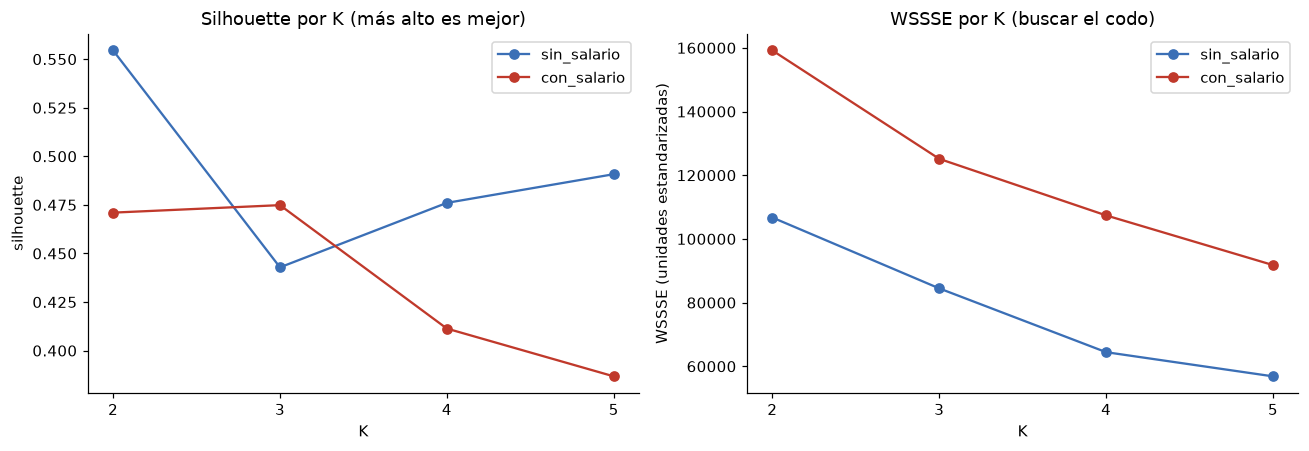

In [40]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4.2))
colores = {"sin_salario": "#3B6FB6", "con_salario": "#C0392B"}
for nombre, t in resultados.items():
    a.plot(t["k"], t["silhouette"], marker="o", color=colores[nombre], label=nombre)
    b.plot(t["k"], t["wssse"], marker="o", color=colores[nombre], label=nombre)
a.set_title("Silhouette por K (más alto es mejor)")
a.set_xlabel("K")
a.set_ylabel("silhouette")
b.set_title("WSSSE por K (buscar el codo)")
b.set_xlabel("K")
b.set_ylabel("WSSSE (unidades estandarizadas)")
for eje in (a, b):
    eje.set_xticks(segmentacion.KS)
    eje.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / "03_eleccion_k.png", dpi=120, bbox_inches="tight")
plt.show()

In [41]:
k_elegido = {nombre: segmentacion.elegir_k(t) for nombre, t in resultados.items()}
for nombre, t in resultados.items():
    fila = t.set_index("k").loc[k_elegido[nombre]]
    mejor_sil = t.loc[t["silhouette"].idxmax()]
    print(f"{nombre}: K elegido = {k_elegido[nombre]} (reducción del WSSSE {fila['wssse_reduccion_pct']:.1f} %, "
          f"silhouette {fila['silhouette']:.3f}, cluster más pequeño {fila['cluster_menor_pct']:.1f} %).")
    print(f"   Mayor silhouette: K = {int(mejor_sil['k'])} ({mejor_sil['silhouette']:.3f}).")
    print("   Reducción del WSSSE al pasar de K-1 a K (%):",
          ", ".join(f"K={int(k)}: {r:.1f}" for k, r in zip(t["k"], t["wssse_reduccion_pct"]) if pd.notna(r)))

K = k_elegido["sin_salario"]
print(f"\nSegmentación principal: sin salario, K = {K}.")

sin_salario: K elegido = 4 (reducción del WSSSE 23.7 %, silhouette 0.476, cluster más pequeño 13.0 %).
   Mayor silhouette: K = 2 (0.554).
   Reducción del WSSSE al pasar de K-1 a K (%): K=3: 20.9, K=4: 23.7, K=5: 11.8
con_salario: K elegido = 3 (reducción del WSSSE 21.4 %, silhouette 0.475, cluster más pequeño 17.7 %).
   Mayor silhouette: K = 3 (0.475).
   Reducción del WSSSE al pasar de K-1 a K (%): K=3: 21.4, K=4: 14.2, K=5: 14.5

Segmentación principal: sin salario, K = 4.


**Interpretación de la elección de K (segmentación sin salario).**

- El mayor silhouette está en **K = 2 (0.55)**, pero esa partición solo separa a las personas mayores con mucha antigüedad (27.5 %) del resto (72.5 %), y la jornada no distingue a los grupos. Es la primera división obvia de los datos, no una segmentación en perfiles.
- El WSSSE baja 20.9 % al pasar de 2 a 3 clusters y **23.7 % de 3 a 4**, pero solo **11.8 % de 4 a 5**: el cuarto cluster todavía aporta una mejora grande y el quinto ya no. El codo está en **K = 4**.
- Con K = 4 el silhouette es **0.48**, prácticamente igual al de K = 5 (0.49) y mayor que el de K = 3 (0.44). K = 5 además genera un cluster con apenas 4.9 % de los registros.
- Un silhouette cercano a 0.5 indica que los perfiles existen pero con fronteras no nítidas: edad, antigüedad y horas son continuas y hay personas en la transición entre un perfil y otro.

## 3. Perfiles de la segmentación principal (sin salario)

Se usa el modelo con el K elegido, ajustado sobre todos los registros de 2025. Los centroides se presentan en unidades estandarizadas (`_z`, desviaciones respecto al promedio) y en unidades originales.

Cada cluster recibe un nombre corto a partir de su centroide estandarizado: un rasgo se menciona cuando el centroide se aleja al menos **media desviación estándar** del promedio (por ejemplo, `edad_z ≥ 0.5` → "mayores"; `horas_semanales_z ≤ −0.5` → "jornada corta").

In [42]:
modelo = modelos["sin_salario"][K]
pred = modelo.transform(pob).persist()

cent = segmentacion.centroides(modelo, segmentacion.VARIABLES_PERFIL)
nombres = segmentacion.nombrar_clusters(cent)
cent.insert(0, "nombre", nombres)
cent.to_csv(config.TABLES / "03_centroides.csv")
cent

,nombre,edad_z,edad,antiguedad_z,antiguedad,horas_semanales_z,horas_semanales
cluster,,,,,,,
0,Mayores,0.99,48.52,-0.19,4.06,-0.37,39.50
1,Jornada larga,-0.34,30.55,-0.26,3.48,1.53,74.76
2,Jóvenes,-0.69,25.82,-0.40,2.42,-0.29,40.95
3,"Mayores, antigüedad alta",1.09,49.90,2.13,22.24,-0.28,41.06


In [43]:
CATEGORIAS = {"1": "Gobierno", "2": "Empresa privada", "3": "Jornalero o peón", "4": "Servicio doméstico"}

perfil = segmentacion.perfil_clusters(pred)
comp = {c: segmentacion.composicion(pred, c) for c in config.CATEGORICAS}
pred_cat = segmentacion.predominante(comp["categoria_ocupacional"])
pred_edu = segmentacion.predominante(comp["nivel_educativo"])
pred_dom = segmentacion.predominante(comp["dominio"])

tabla_perfil = pd.DataFrame({
    "nombre": nombres,
    "registros": perfil["registros"],
    "porcentaje": perfil["porcentaje"],
    "edad_mediana": perfil["edad_mediana"],
    "antiguedad_mediana": perfil["antiguedad_mediana"],
    "horas_mediana": perfil["horas_semanales_mediana"],
    "salario_p25": perfil["salario_mensual_p25"],
    "salario_mediano": perfil["salario_mensual_mediana"],
    "salario_p75": perfil["salario_mensual_p75"],
    "salario_medio": perfil["salario_mensual_media"],
    "categoria_predominante": [f"{CATEGORIAS.get(c, c)} ({p:.0f} %)" for c, p in zip(pred_cat["categoria"], pred_cat["porcentaje"])],
    "educacion_predominante": [f"código {c} ({p:.0f} %)" for c, p in zip(pred_edu["categoria"], pred_edu["porcentaje"])],
    "dominio_predominante": [f"código {c} ({p:.0f} %)" for c, p in zip(pred_dom["categoria"], pred_dom["porcentaje"])],
})
tabla_perfil.to_csv(config.TABLES / "03_perfil_clusters.csv")
tabla_perfil

,nombre,registros,porcentaje,edad_mediana,antiguedad_mediana,horas_mediana,salario_p25,salario_mediano,salario_p75,salario_medio,categoria_predominante,educacion_predominante,dominio_predominante
0,Mayores,12742,24.03,46.00,3.00,42.00,"1,500.00","3,000.00","4,000.00","3,536.70",Empresa privada (46 %),código 2 (36 %),código 1 (47 %)
1,Jornada larga,8928,16.84,29.00,2.00,72.00,"2,000.00","3,000.00","3,900.00","3,240.87",Empresa privada (67 %),código 4 (34 %),código 2 (43 %)
2,Jóvenes,24488,46.18,26.00,1.25,44.00,"1,600.00","3,000.00","3,900.00","3,074.74",Empresa privada (57 %),código 4 (38 %),código 1 (41 %)
3,"Mayores, antigüedad alta",6867,12.95,48.00,20.00,40.00,"2,250.00","3,800.00","6,000.00","4,680.57",Empresa privada (40 %),código 2 (28 %),código 1 (44 %)


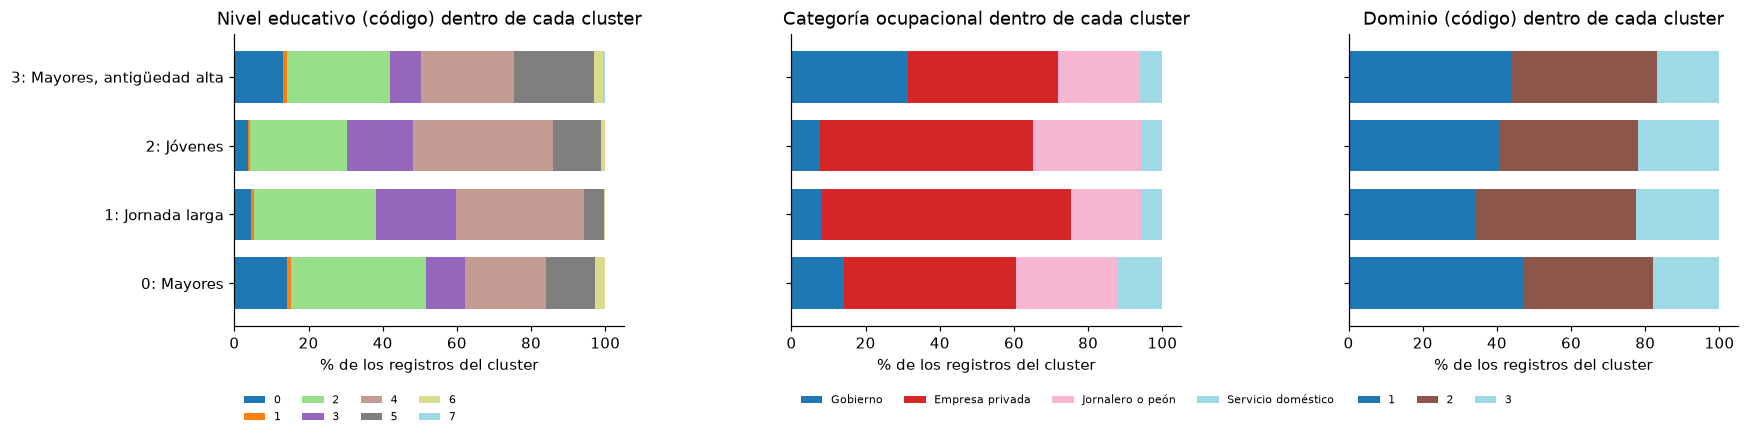

In [44]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.2))
titulos = {"categoria_ocupacional": "Categoría ocupacional", "nivel_educativo": "Nivel educativo (código)", "dominio": "Dominio (código)"}
for eje, (col, t) in zip(ejes, comp.items()):
    t = t.rename(columns=CATEGORIAS) if col == "categoria_ocupacional" else t
    t.index = [f"{c}: {nombres[c]}" for c in t.index]
    t.plot.barh(stacked=True, ax=eje, width=.75, colormap="tab20", legend=False)
    eje.set_title(f"{titulos[col]} dentro de cada cluster")
    eje.set_xlabel("% de los registros del cluster")
    eje.legend(fontsize=7, ncol=4, loc="upper left", bbox_to_anchor=(0, -0.2), frameon=False)
for eje in ejes[1:]:
    eje.set_yticklabels([])
plt.tight_layout()
plt.savefig(config.FIGURES / "03_composicion_clusters.png", dpi=120, bbox_inches="tight")
plt.show()

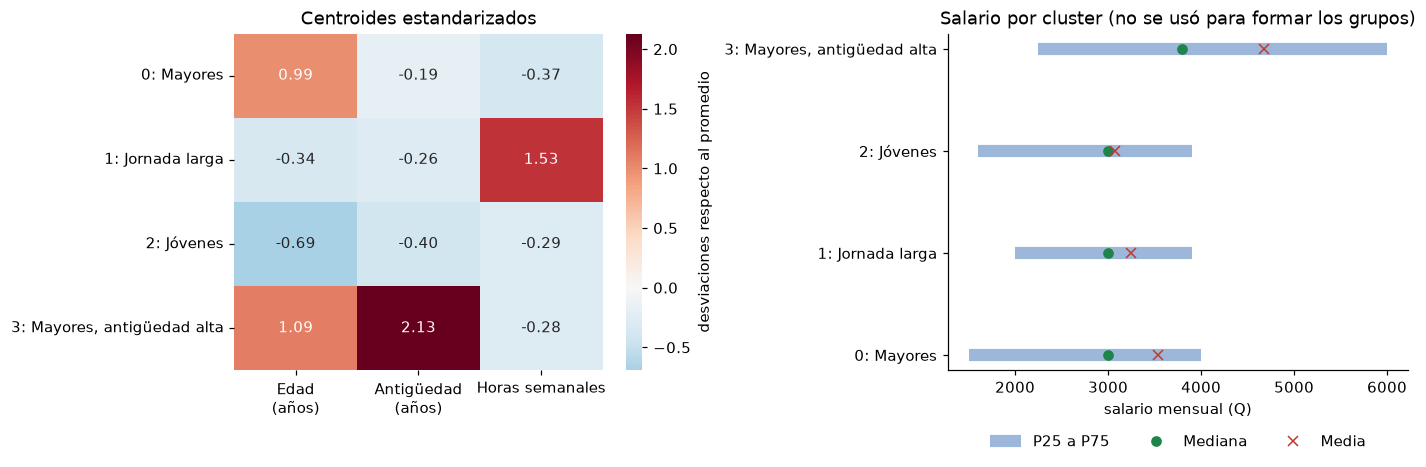

In [45]:
fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.4))
z = cent[[f"{v}_z" for v in segmentacion.VARIABLES_PERFIL]]
z.columns = [segmentacion.ETIQUETAS[v].replace(" (", "\n(") for v in segmentacion.VARIABLES_PERFIL]
z.index = [f"{c}: {nombres[c]}" for c in z.index]
sns.heatmap(z, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=a, cbar_kws={"label": "desviaciones respecto al promedio"})
a.set_title("Centroides estandarizados")
a.set_ylabel("")
a.tick_params(axis="x", rotation=0)

etiquetas = [f"{c}: {nombres[c]}" for c in tabla_perfil.index]
y = np.arange(len(tabla_perfil))
b.hlines(y, tabla_perfil["salario_p25"], tabla_perfil["salario_p75"], color="#9DB7DB", lw=8, label="P25 a P75")
b.plot(tabla_perfil["salario_mediano"], y, "o", color="#1E8449", label="Mediana")
b.plot(tabla_perfil["salario_medio"], y, "x", color="#C0392B", label="Media")
b.set_yticks(y, etiquetas)
b.set_xlabel("salario mensual (Q)")
b.set_title("Salario por cluster (no se usó para formar los grupos)")
b.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig(config.FIGURES / "03_centroides_y_salario.png", dpi=120, bbox_inches="tight")
plt.show()

### Visualización con una muestra

La proyección en dos componentes principales (PCA) se ajusta con **todos** los registros sobre las variables estandarizadas; solo se dibuja una muestra aleatoria de hasta 5,000 registros.

Registros dibujados: 5,000. Varianza explicada: PC1 50.5 %, PC2 32.5 % (total 83.0 %).


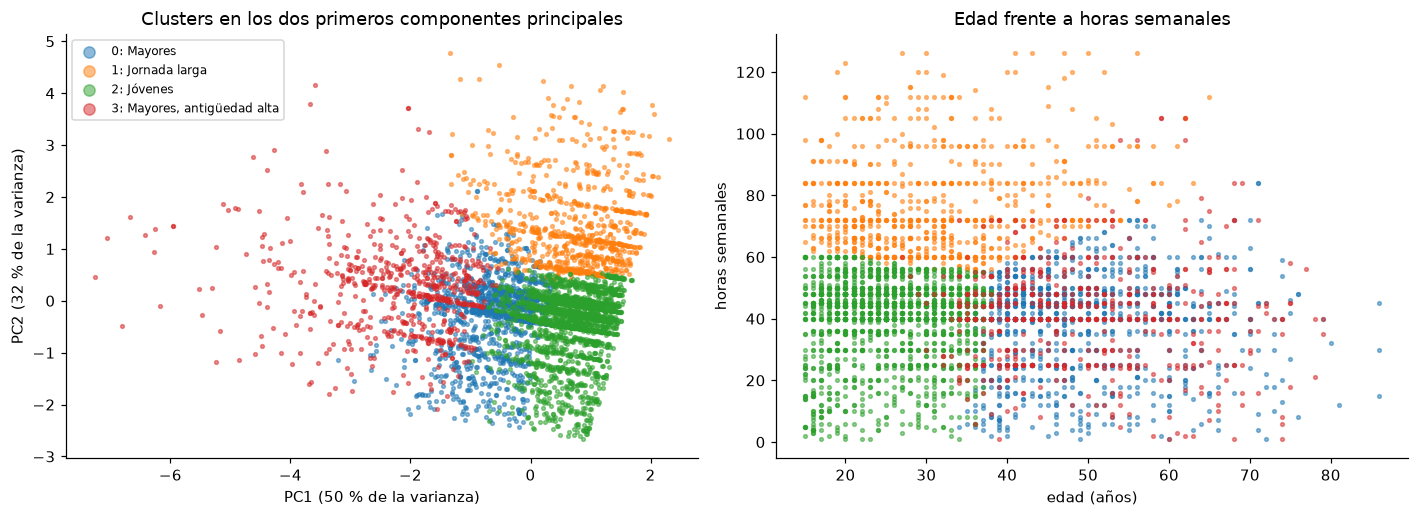

In [46]:
muestra_pca, varianza = segmentacion.proyeccion_pca(pred, n=5000)
print(f"Registros dibujados: {len(muestra_pca):,}. Varianza explicada: PC1 {100 * varianza[0]:.1f} %, PC2 {100 * varianza[1]:.1f} % (total {100 * sum(varianza):.1f} %).")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8))
paleta = dict(zip(sorted(nombres.index), sns.color_palette("tab10", len(nombres))))
for c, g in muestra_pca.groupby("cluster"):
    a.scatter(g["pc1"], g["pc2"], s=6, alpha=.5, color=paleta[c], label=f"{c}: {nombres[c]}")
    b.scatter(g["edad"], g["horas_semanales"], s=6, alpha=.5, color=paleta[c])
a.set_title("Clusters en los dos primeros componentes principales")
a.set_xlabel(f"PC1 ({100 * varianza[0]:.0f} % de la varianza)")
a.set_ylabel(f"PC2 ({100 * varianza[1]:.0f} % de la varianza)")
a.legend(markerscale=3, fontsize=8)
b.set_title("Edad frente a horas semanales")
b.set_xlabel("edad (años)")
b.set_ylabel("horas semanales")
plt.tight_layout()
plt.savefig(config.FIGURES / "03_clusters_muestra.png", dpi=120, bbox_inches="tight")
plt.show()

### Descripción de cada cluster

La descripción se genera con los valores calculados arriba (medianas, categoría y nivel educativo predominantes, salario mediano).

In [47]:
mediana_global = pred.approxQuantile("salario_mensual", [0.5], 0.0)[0]
for c, f in tabla_perfil.iterrows():
    relacion = f["salario_mediano"] / mediana_global
    print(f"Cluster {c} — {f['nombre']} ({f['registros']:,} registros, {f['porcentaje']:.1f} %)")
    print(f"   Edad mediana {f['edad_mediana']:.0f} años, antigüedad mediana {f['antiguedad_mediana']:.1f} años, "
          f"{f['horas_mediana']:.0f} horas semanales.")
    print(f"   Categoría predominante: {f['categoria_predominante']}; educación predominante: {f['educacion_predominante']}; "
          f"dominio predominante: {f['dominio_predominante']}.")
    print(f"   Salario mediano Q{f['salario_mediano']:,.0f} ({relacion:.2f} veces la mediana general de Q{mediana_global:,.0f}); "
          f"rango intercuartílico Q{f['salario_p25']:,.0f} a Q{f['salario_p75']:,.0f}.\n")

Cluster 0 — Mayores (12,742 registros, 24.0 %)
   Edad mediana 46 años, antigüedad mediana 3.0 años, 42 horas semanales.
   Categoría predominante: Empresa privada (46 %); educación predominante: código 2 (36 %); dominio predominante: código 1 (47 %).
   Salario mediano Q3,000 (1.00 veces la mediana general de Q3,000); rango intercuartílico Q1,500 a Q4,000.

Cluster 1 — Jornada larga (8,928 registros, 16.8 %)
   Edad mediana 29 años, antigüedad mediana 2.0 años, 72 horas semanales.
   Categoría predominante: Empresa privada (67 %); educación predominante: código 4 (34 %); dominio predominante: código 2 (43 %).
   Salario mediano Q3,000 (1.00 veces la mediana general de Q3,000); rango intercuartílico Q2,000 a Q3,900.

Cluster 2 — Jóvenes (24,488 registros, 46.2 %)
   Edad mediana 26 años, antigüedad mediana 1.2 años, 44 horas semanales.
   Categoría predominante: Empresa privada (57 %); educación predominante: código 4 (38 %); dominio predominante: código 1 (41 %).
   Salario mediano Q3

**Interpretación de los perfiles (K = 4).**

| Cluster | Perfil | Registros | Rasgos (medianas) | Salario mediano (P25–P75) | Lo que lo distingue |
|---|---|---|---|---|---|
| 2 | **Jóvenes al inicio de su trayectoria** | 46.2 % | 26 años, 1.2 años de antigüedad, 44 h | Q3,000 (Q1,600–Q3,900) | Es el grupo más grande; 57 % en empresa privada y 29 % jornaleros; el nivel educativo más frecuente es el código 4 (38 %). |
| 1 | **Jornada extendida** | 16.8 % | 29 años, 2 años de antigüedad, **72 h** | Q3,000 (Q2,000–Q3,900) | Trabaja cerca de 30 horas más por semana que los demás con el mismo salario mediano; 67 % en empresa privada. |
| 0 | **Adultos mayores con poca antigüedad** | 24.0 % | 46 años, 3 años de antigüedad, 42 h | Q3,000 (Q1,500–Q4,000) | Llegaron hace poco a su empleo actual; mayor presencia de personas sin educación (código 0, 14 %), jornaleros (27 %) y servicio doméstico (12 %). |
| 3 | **Trayectoria larga y estable** | 13.0 % | 48 años, **20 años de antigüedad**, 40 h | **Q3,800 (Q2,250–Q6,000)** | Único perfil con salario claramente mayor; concentra el empleo de gobierno (31 % frente a 12 % en toda la muestra) y los niveles educativos más altos (código 5, 22 %). |

- Tres de los cuatro perfiles tienen **el mismo salario mediano (Q3,000)**: la edad y la jornada, por sí solas, no se asocian con un salario mediano distinto. Lo que sí acompaña a un salario mayor es la **antigüedad larga**, que a su vez se mezcla con el empleo de gobierno y con más educación.
- El perfil de **jornada extendida** gana lo mismo trabajando 72 horas en lugar de 40–44: su ingreso por hora es menor. Es coherente con la correlación casi nula entre horas y salario (r = 0.08).
- Los grupos se forman **solo** con edad, antigüedad y horas. Que después muestren salarios, categorías o niveles educativos distintos indica que esas características **acompañan** al perfil laboral; no significa que el perfil los cause.
- La antigüedad está limitada por la edad (filtro de la sección 01), por lo que los perfiles de mayor antigüedad son también de mayor edad. Lo que distingue a los perfiles jóvenes entre sí es sobre todo la **jornada**.
- La separación moderada (silhouette) significa que hay personas en la frontera entre dos perfiles. Los nombres describen el **centro** de cada grupo, no a cada una de sus personas.
- Los porcentajes describen los registros analizados de 2025 (sin ponderar). Con `FACTOR` se podría estimar cuántos trabajadores del país hay en cada perfil, pero eso requeriría el análisis ponderado y el diseño muestral completo.

## 4. Contraste: segmentación con salario

Se revisa qué perfiles aparecen si el `log10(salario)` entra en la segmentación, con el K elegido para esa especificación según el mismo criterio.

In [48]:
K_sal = k_elegido["con_salario"]
modelo_sal = modelos["con_salario"][K_sal]
pred_sal = modelo_sal.transform(pob)

cent_sal = segmentacion.centroides(modelo_sal, segmentacion.VARIABLES_CON_SALARIO)
cent_sal.insert(0, "nombre", segmentacion.nombrar_clusters(cent_sal))
cent_sal["salario_centroide_Q"] = 10 ** cent_sal[segmentacion.SALARIO_LOG]
perfil_sal = segmentacion.perfil_clusters(pred_sal)
cent_sal["registros"] = perfil_sal["registros"]
cent_sal["porcentaje"] = perfil_sal["porcentaje"]
cent_sal.to_csv(config.TABLES / "03_centroides_con_salario.csv")
cent_sal[["nombre", "registros", "porcentaje", "edad", "antiguedad", "horas_semanales", "salario_centroide_Q",
          "edad_z", "antiguedad_z", "horas_semanales_z", f"{segmentacion.SALARIO_LOG}_z"]]

,nombre,registros,porcentaje,edad,antiguedad,horas_semanales,salario_centroide_Q,edad_z,antiguedad_z,horas_semanales_z,salario_log10_z
cluster,,,,,,,,,,,
0,Perfil promedio,33229,62.67,30.19,2.66,52.78,"3,184.57",-0.37,-0.37,0.35,0.25
1,"Mayores, antigüedad alta",10406,19.62,51.02,17.25,43.64,"3,878.85",1.17,1.49,-0.14,0.50
2,"Jornada corta, salario bajo",9390,17.71,35.32,2.88,26.34,829.96,0.01,-0.34,-1.07,-1.44


In [49]:
t_sin = resultados["sin_salario"].set_index("k").loc[K]
t_con = resultados["con_salario"].set_index("k").loc[K_sal]
print(f"Sin salario: K = {K}, silhouette {t_sin['silhouette']:.3f}, cluster más pequeño {t_sin['cluster_menor_pct']:.1f} %.")
print(f"Con salario: K = {K_sal}, silhouette {t_con['silhouette']:.3f}, cluster más pequeño {t_con['cluster_menor_pct']:.1f} %.")
z_sal = cent_sal[f"{segmentacion.SALARIO_LOG}_z"]
print(f"Con salario, los centroides del log10(salario) van de {z_sal.min():+.2f} a {z_sal.max():+.2f} desviaciones estándar: "
      f"{'el salario es uno de los ejes principales de la segmentación' if (z_sal.max() - z_sal.min()) >= 1 else 'el salario separa poco a los grupos'}.")

Sin salario: K = 4, silhouette 0.476, cluster más pequeño 13.0 %.
Con salario: K = 3, silhouette 0.475, cluster más pequeño 17.7 %.
Con salario, los centroides del log10(salario) van de -1.44 a +0.50 desviaciones estándar: el salario es uno de los ejes principales de la segmentación.


**¿Vale la pena incluir el salario?**

- Con salario, el codo está en **K = 3** con silhouette **0.47**, similar al de la segmentación sin salario (0.48): incluirlo **no mejora** la separación.
- Lo que cambia es el contenido. Aparece un grupo de **jornada corta y salario bajo** (17.7 %: 25 horas y salario mediano de Q960, con 52 % de jornaleros y 24 % de servicio doméstico), cuyo rasgo principal es el propio salario (−1.44 desviaciones). Los otros dos grupos repiten a los jóvenes y a los de trayectoria larga que ya aparecían sin salario.
- Es decir, con salario la segmentación se ordena en parte por **tramo de ingreso** y no por perfil laboral, y deja de servir para preguntar si perfiles distintos ganan distinto.

La decisión del grupo es mantener la segmentación **sin salario** como principal: responde a la pregunta planteada (perfiles según edad, antigüedad y jornada), deja el salario como variable de **descripción** para comparar perfiles, y evita construir los grupos con la misma variable que se quiere estimar en la segunda parte. La etiqueta de cluster **no** se usa como predictor en los modelos supervisados.

## 5. Modelo guardado

Se guarda el pipeline completo (ensamblador, escalador y KMeans) de la segmentación principal en `results/modelos/` (no se versiona).

In [50]:
ruta_modelo = config.MODELOS / f"kmeans_sin_salario_k{K}"
modelo.write().overwrite().save(str(ruta_modelo))
print("Modelo guardado en", ruta_modelo.relative_to(RAIZ))

Modelo guardado en results/modelos/kmeans_sin_salario_k4


In [51]:
pred.unpersist()
pob.unpersist()
spark.stop()